# FaceRankNet — Master Colab Notebook
**Feature-Decomposed Facial Beauty Prediction**  
Dataset: SCUT-FBP5500 | Framework: PyTorch + DGL + MediaPipe

---
**Drive folder structure:**
```
MyDrive/Colab Notebooks/FaceRankNet/FaceRankNet/
  ├── config.py, preprocessing.py, dataset.py, model.py ...
  ├── run_colab.ipynb
  └── cache/   <- auto-created, persists across sessions
```
Run cells **in order**.

In [1]:
import sys, os

# Install DGL without touching torch or numpy (--no-deps)
!pip install dgl --no-deps -f https://data.dgl.ai/wheels/cu121/repo.html -q

# MediaPipe & CV
!pip install -q "mediapipe>=0.10" opencv-python-headless

# Scientific stack
!pip install -q pandas scikit-learn tqdm matplotlib scipy

# DGL dependency
!pip install -q torchdata

# Kaggle dataset downloader
!pip install -q kagglehub

print("Done. Continue to Cell 2.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.5/467.5 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 15.6 MB/s eta 0:00:00
Done. Continue to Cell 2.


In [2]:

import sys, types

if 'dgl.graphbolt' not in sys.modules:
    _gb = types.ModuleType('dgl.graphbolt')
    _gb.load_graphbolt = lambda: None
    sys.modules['dgl.graphbolt'] = _gb
    print('✓ DGL graphbolt pre-patched')

import dgl, torch
print(f'DGL     : {dgl.__version__}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')

# Sanity check: confirm DGL can move a graph to GPU
if torch.cuda.is_available():
    _g = dgl.graph(([0], [1]))
    _g = _g.to('cuda')
    print('✓ DGL CUDA graph test passed')
else:
    print('⚠ No GPU detected — re-check Runtime -> Change runtime type -> T4 GPU')

✓ DGL graphbolt pre-patched
Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)


DGL backend not selected or invalid.  Assuming PyTorch for now.


DGL     : 2.1.0+cu121
PyTorch : 2.11.0+cu128
CUDA    : True
✓ DGL CUDA graph test passed


In [3]:
# ============================================================
# Cell 3 — Mount Drive, copy project files, download dataset
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os, sys, shutil
import pandas as pd
import kagglehub
from sklearn.model_selection import train_test_split

DRIVE_ROOT   = '/content/drive/MyDrive/Colab Notebooks/FaceRankNet4'
PROJECT_ROOT = '/content/FaceRankNet'
CACHE_DIR    = f'{DRIVE_ROOT}/cache'
os.makedirs(PROJECT_ROOT, exist_ok=True)
os.makedirs(CACHE_DIR,    exist_ok=True)

copied = []
for fname in os.listdir(DRIVE_ROOT):
    if fname.endswith('.py'):
        shutil.copy(os.path.join(DRIVE_ROOT, fname),
                    os.path.join(PROJECT_ROOT, fname))
        copied.append(fname)
sys.path.insert(0, PROJECT_ROOT)
print(f'Copied {len(copied)} files: {copied}')

print('\nDownloading SCUT-FBP5500 ...')
KAGGLE_PATH = kagglehub.dataset_download(
    'pranavchandane/scut-fbp5500-v2-facial-beauty-scores')
print('Downloaded to:', KAGGLE_PATH)

IMAGE_DIR   = os.path.join(KAGGLE_PATH, 'Images', 'Images')
LABELS_FILE = os.path.join(KAGGLE_PATH, 'labels.txt')

if not os.path.isdir(IMAGE_DIR):
    for root, _, files in os.walk(KAGGLE_PATH):
        if any(f.lower().endswith(('.jpg','.png')) for f in files):
            IMAGE_DIR = root; break
if not os.path.isfile(LABELS_FILE):
    for root, _, files in os.walk(KAGGLE_PATH):
        if 'labels.txt' in files:
            LABELS_FILE = os.path.join(root,'labels.txt'); break

n_img = len([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.jpg','.png'))])
print(f'Image dir: {IMAGE_DIR}  ({n_img} images)')

df = pd.read_csv(LABELS_FILE, sep=' ', header=None, names=['Filename','Rating'])

# H1: parse ethnicity from filename prefix (A=Asian, C=Caucasian)
df['Ethnicity'] = df['Filename'].apply(
    lambda f: 'Asian' if f[0].upper() == 'A' else 'Caucasian')
print('Ethnicity dist:', df['Ethnicity'].value_counts().to_dict())

# Parse gender from filename's 2nd char (F=Female, M=Male).
# Used only for pseudo-label diagnostics + multi-prototype benchmarks —
# the dataloader / loss do not consume Gender yet.
df['Gender'] = df['Filename'].apply(
    lambda f: 'Female' if f[1].upper() == 'F' else 'Male')
print('Gender dist:', df['Gender'].value_counts().to_dict())

df['_b'] = df['Rating'].round(0).astype(int).clip(1,5)
train_df, test_df = train_test_split(df.drop(columns=['_b']),
    test_size=0.20, random_state=42, stratify=df['_b'])
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

TRAIN_CSV     = f'{DRIVE_ROOT}/train_labels.csv'
TEST_CSV      = f'{DRIVE_ROOT}/test_labels.csv'
CACHE_TRAIN   = f'{CACHE_DIR}/train_landmarks.pkl'
CACHE_TEST    = f'{CACHE_DIR}/test_landmarks.pkl'
AVG_FACE_PATH = f'{CACHE_DIR}/avg_face.npy'
PSEUDO_PATH   = f'{CACHE_DIR}/pseudo_labels.pkl'
CHECKPOINT    = f'{DRIVE_ROOT}/checkpoint_best.pt'

train_df.to_csv(TRAIN_CSV, index=False)
test_df.to_csv(TEST_CSV,   index=False)

print(f'Train: {len(train_df)} | Test: {len(test_df)}')
print(f'All paths ready. CHECKPOINT: {CHECKPOINT}')


Mounted at /content/drive
Copied 9 files: ['loss.py', 'preprocessing.py', 'evaluate.py', 'model.py', 'pseudo_labels.py', 'config.py', 'organ_indices.py', 'dataset.py', 'train.py']



100%|██████████| 1.12G/1.12G [00:12<00:00, 98.1MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/pranavchandane/scut-fbp5500-v2-facial-beauty-scores/versions/2
Image dir: /root/.cache/kagglehub/datasets/pranavchandane/scut-fbp5500-v2-facial-beauty-scores/versions/2/Images/Images  (5500 images)
Ethnicity dist: {'Asian': 4000, 'Caucasian': 1500}
Gender dist: {'Female': 2750, 'Male': 2750}
Train: 4400 | Test: 1100
All paths ready. CHECKPOINT: /content/drive/MyDrive/Colab Notebooks/FaceRankNet4/checkpoint_best.pt


In [4]:
# ============================================================
# Cell 4 — Extract & cache landmarks  (~20-40 min, saved to Drive)
# Skips extraction jika cache .pkl sudah ada di Drive.
# ============================================================
import os, pickle
from preprocessing import preprocess_dataset

if os.path.exists(CACHE_TRAIN):
    print(f'✓ Cache ditemukan: {CACHE_TRAIN} — load saja (skip extraction)')
    with open(CACHE_TRAIN, 'rb') as f:
        train_coords = pickle.load(f)
else:
    print('Processing TRAIN set ...')
    train_coords = preprocess_dataset(
        image_dir=IMAGE_DIR, csv_path=TRAIN_CSV, cache_path=CACHE_TRAIN)

if os.path.exists(CACHE_TEST):
    print(f'✓ Cache ditemukan: {CACHE_TEST} — load saja (skip extraction)')
    with open(CACHE_TEST, 'rb') as f:
        test_coords = pickle.load(f)
else:
    print('\nProcessing TEST set ...')
    test_coords = preprocess_dataset(
        image_dir=IMAGE_DIR, csv_path=TEST_CSV, cache_path=CACHE_TEST)

print(f'✓ Train: {len(train_coords)} | Test: {len(test_coords)} faces')


Processing TRAIN set ...


Extracting landmarks: 100%|██████████| 4400/4400 [01:29<00:00, 49.11img/s]



Processing TEST set ...


Extracting landmarks: 100%|██████████| 1100/1100 [00:22<00:00, 48.21img/s]

✓ Train: 4400 | Test: 1100 faces


In [5]:
# ============================================================
# Cell 5 — Beauty-Axis Pseudo Labels (H1 — per ethnicity)
# Skips heavy compute jika avg_face.npy + pseudo_labels.pkl sudah ada.
# ============================================================
import os, pickle, numpy as np, pandas as pd
from pseudo_labels import (
    compute_universal_average_face,
    compute_beauty_prototype,
    compute_ethnicity_avg_faces,
    compute_all_pseudo_labels_beauty_axis,
    validate_pseudo_label_quality,
    pseudo_label_quality_report,
    save_avg_face, save_pseudo_labels,
    load_pseudo_labels, load_avg_face,
)

train_df_loaded = pd.read_csv(TRAIN_CSV)
train_filenames = train_df_loaded["Filename"].tolist()
holistic_map    = dict(zip(train_df_loaded["Filename"],
                           train_df_loaded["Rating"].astype(float)))
ethnicity_map   = dict(zip(train_df_loaded["Filename"],
                           train_df_loaded["Ethnicity"]))
gender_map      = dict(zip(train_df_loaded["Filename"],
                           train_df_loaded["Gender"]))

cache_hit = os.path.exists(AVG_FACE_PATH) and os.path.exists(PSEUDO_PATH)

if cache_hit:
    print(f'✓ Cache ditemukan: {AVG_FACE_PATH}')
    print(f'✓ Cache ditemukan: {PSEUDO_PATH}')
    population_mean = load_avg_face(AVG_FACE_PATH)
    pseudo_labels   = load_pseudo_labels(PSEUDO_PATH)
else:
    if 'train_coords' not in globals():
        with open(CACHE_TRAIN, 'rb') as f:
            train_coords = pickle.load(f)

    train_coords_list = [train_coords[f] for f in train_filenames if f in train_coords]
    train_ratings     = [holistic_map[f] for f in train_filenames if f in train_coords]

    # 1) Global population mean & beauty prototype
    population_mean  = compute_universal_average_face(train_coords_list)
    beauty_prototype = compute_beauty_prototype(train_coords_list, train_ratings,
                                                top_k_pct=0.30)

    # 2) Per-ethnicity population means (tanpa top-k filter)
    population_mean_map = compute_ethnicity_avg_faces(
        train_coords, train_filenames, ethnicity_map,
        holistic_ratings=None,
    )

    # 3) Per-ethnicity beauty prototypes (top-30% per ethnicity)
    beauty_prototype_map = compute_ethnicity_avg_faces(
        train_coords, train_filenames, ethnicity_map,
        holistic_ratings=holistic_map,
        top_k_pct=0.30,
    )

    print(f"Per-ethnicity population means: { {k: v.shape for k, v in population_mean_map.items()} }")
    print(f"Per-ethnicity beauty prototypes: { {k: v.shape for k, v in beauty_prototype_map.items()} }")

    # 4) Pseudo-labels via Beauty Axis Projection
    pseudo_labels = compute_all_pseudo_labels_beauty_axis(
        coords_cache=train_coords,
        train_filenames=train_filenames,
        population_mean=population_mean,
        beauty_prototype=beauty_prototype,
        population_mean_map=population_mean_map,
        beauty_prototype_map=beauty_prototype_map,
        ethnicity_map=ethnicity_map,
    )

    # 5) Save
    save_avg_face(population_mean, AVG_FACE_PATH)
    save_pseudo_labels(pseudo_labels, PSEUDO_PATH)

# Diagnostic Spearman rho (cheap — always run)
rho = validate_pseudo_label_quality(pseudo_labels, holistic_map)
print(f'Spearman rho after Beauty Axis: {rho:.4f}')

# Detailed quality breakdown for the cached/current pseudo-labels.
# Same numbers feed into the Cell 5b benchmark leaderboard.
_ = pseudo_label_quality_report(
    pseudo_labels, holistic_map,
    ethnicity_map=ethnicity_map,
    gender_map=gender_map,
    method_name='axis_eth (baseline / cached)',
)

# Sample sanity check
for sample in ["CF137.jpg", "CF581.jpg", "AF1859.jpg", "AF549.jpg"]:
    if sample in pseudo_labels:
        organs = pseudo_labels[sample]
        mean_score = sum(organs.values()) / len(organs)
        print(f'\n{sample}  rating={holistic_map.get(sample, "?"):.3f}  mean_pseudo={mean_score:.3f}')
        for organ, score in organs.items():
            print(f"  {organ:<12}: {score:.3f}")


Per-ethnicity population means: {'Caucasian': (468, 3), 'Asian': (468, 3)}
Per-ethnicity beauty prototypes: {'Caucasian': (468, 3), 'Asian': (468, 3)}


Pass 2 — pseudo scores: 100%|██████████| 4400/4400 [00:00<00:00, 6550.71face/s]


Spearman rho after Beauty Axis: 0.5740

========== Pseudo-Label Quality Report: axis_eth (baseline / cached) ==========
  n=4400  Spearman rho=0.5740  Pearson r=0.5664

  Per organ:
    left_eye    rho=+0.4472  n=4400
    right_eye   rho=+0.4773  n=4400
    nose        rho=+0.5833  n=4400
    mouth       rho=+0.5668  n=4400
    jawline     rho=+0.5593  n=4400
  Per ethnicity:
    Caucasian   rho=+0.5582  n=1222
    Asian       rho=+0.5772  n=3178
  Per gender:
    Female      rho=+0.5745  n=2209
    Male        rho=+0.5282  n=2191
  Per (eth x gen):
    Caucasian_Female     rho=+0.5677  n=612
    Asian_Female         rho=+0.5888  n=1597
    Asian_Male           rho=+0.5124  n=1581
    Caucasian_Male       rho=+0.5261  n=610
  Per rating bucket:
    Jelek (<2)     rho=-0.0910  n=188
    Avg (2-3)      rho=+0.2306  n=2412
    Mid (3-4)      rho=+0.2653  n=1294
    Cantik (>=4)   rho=+0.0258  n=506


CF137.jpg  rating=2.933  mean_pseudo=4.227
  left_eye    : 2.355
  right_eye   : 4.991
  

In [6]:
# ============================================================
# Cell 5b — Pseudo-Label Method Benchmark
#
# Generates several pseudo-label candidates from the SAME landmark cache,
# scores each one via pseudo_label_quality_report(), prints a leaderboard
# ranked by global Spearman rho. The winning method is NOT auto-saved —
# inspect the table, then re-run Cell 5c / 5d with the chosen generator.
#
# Methods compared:
#   1. rmse_eth                    — RMSE-to-prototype, per ethnicity (legacy)
#   2. axis_eth                    — beauty-axis projection, per ethnicity (current)
#   3. axis_eth_gen                — beauty-axis projection, per (eth x gen)
#   4. axis_eth_kmeans             — beauty-axis projection w/ K=3 sub-prototypes
#   5. axis_eth_quantile           — axis_eth re-shaped to GT distribution
#   6. axis_eth_synthaug           — pseudo-label-time MixUp + quantile
#   7. symmetry                    — bilateral symmetry only (standalone)
#   8. canons                      — neoclassical canon deviations only
#   9. axis_quantile_canons_sym    — equal-weight blend of #5 + #7 + #8
# ============================================================
import os, pickle
import numpy as np
from pseudo_labels import (
    compute_universal_average_face,
    compute_beauty_prototype,
    compute_ethnicity_avg_faces,
    compute_subgroup_avg_faces,
    compute_all_pseudo_labels,
    compute_all_pseudo_labels_beauty_axis,
    compute_all_pseudo_labels_beauty_axis_kmeans,
    compute_all_pseudo_labels_quantile,
    compute_all_pseudo_labels_axis_synthaug,
    compute_all_pseudo_labels_symmetry,
    compute_all_pseudo_labels_canons,
    compute_all_pseudo_labels_blend,
    pseudo_label_quality_report,
    print_benchmark_leaderboard,
)

# Ensure landmarks are in memory (Cell 4/5 normally load this)
if 'train_coords' not in globals():
    with open(CACHE_TRAIN, 'rb') as f:
        train_coords = pickle.load(f)
    print(f'✓ Loaded train_coords from {CACHE_TRAIN}')

# Composite subgroup key: "Asian_Female", "Asian_Male", ...
subgroup_map = {
    f: f"{ethnicity_map.get(f, 'Unknown')}_{gender_map.get(f, 'Unknown')}"
    for f in train_filenames
}

# Precompute the shared building blocks used by several methods
train_coords_list = [train_coords[f] for f in train_filenames if f in train_coords]
train_ratings     = [holistic_map[f] for f in train_filenames if f in train_coords]

population_mean       = compute_universal_average_face(train_coords_list)
beauty_prototype      = compute_beauty_prototype(
    train_coords_list, train_ratings, top_k_pct=0.30)

pop_mean_eth_map      = compute_ethnicity_avg_faces(
    train_coords, train_filenames, ethnicity_map, holistic_ratings=None)
beauty_proto_eth_map  = compute_ethnicity_avg_faces(
    train_coords, train_filenames, ethnicity_map,
    holistic_ratings=holistic_map, top_k_pct=0.30)

pop_mean_subg_map     = compute_subgroup_avg_faces(
    train_coords, train_filenames, subgroup_map, holistic_ratings=None)
beauty_proto_subg_map = compute_subgroup_avg_faces(
    train_coords, train_filenames, subgroup_map,
    holistic_ratings=holistic_map, top_k_pct=0.30)

# ------------------------------------------------------------------
# 1. RMSE-to-prototype, per ethnicity  (legacy method)
# ------------------------------------------------------------------
print('\n[1/9] Generating rmse_eth ...')
pseudo_rmse_eth = compute_all_pseudo_labels(
    coords_cache=train_coords,
    avg_face=population_mean,
    train_filenames=train_filenames,
    avg_face_map=beauty_proto_eth_map,
    ethnicity_map=ethnicity_map,
)

# ------------------------------------------------------------------
# 2. Beauty-axis projection, per ethnicity
# ------------------------------------------------------------------
print('\n[2/9] Generating axis_eth ...')
pseudo_axis_eth = compute_all_pseudo_labels_beauty_axis(
    coords_cache=train_coords,
    train_filenames=train_filenames,
    population_mean=population_mean,
    beauty_prototype=beauty_prototype,
    population_mean_map=pop_mean_eth_map,
    beauty_prototype_map=beauty_proto_eth_map,
    ethnicity_map=ethnicity_map,
)

# ------------------------------------------------------------------
# 3. Beauty-axis projection, per (ethnicity x gender)
# ------------------------------------------------------------------
print('\n[3/9] Generating axis_eth_gen ...')
pseudo_axis_eth_gen = compute_all_pseudo_labels_beauty_axis(
    coords_cache=train_coords,
    train_filenames=train_filenames,
    population_mean=population_mean,
    beauty_prototype=beauty_prototype,
    population_mean_map=pop_mean_subg_map,
    beauty_prototype_map=beauty_proto_subg_map,
    ethnicity_map=subgroup_map,
)

# ------------------------------------------------------------------
# 4. K-Means multi-prototype (K=3) per ethnicity
# ------------------------------------------------------------------
print('\n[4/9] Generating axis_eth_kmeans ...')
pseudo_axis_eth_kmeans = compute_all_pseudo_labels_beauty_axis_kmeans(
    coords_cache=train_coords,
    train_filenames=train_filenames,
    holistic_ratings=holistic_map,
    ethnicity_map=ethnicity_map,
    top_k_pct=0.30,
    k_clusters=3,
)

# ------------------------------------------------------------------
# 5. Quantile-matched axis_eth (post-process, preserves rank ordering)
# ------------------------------------------------------------------
print('\n[5/9] Generating axis_eth_quantile ...')
pseudo_axis_eth_quantile = compute_all_pseudo_labels_quantile(
    base_pseudo_labels=pseudo_axis_eth,
    holistic_ratings=holistic_map,
)

# ------------------------------------------------------------------
# 6. Pseudo-label-time MixUp + quantile
# ------------------------------------------------------------------
print('\n[6/9] Generating axis_eth_synthaug (also synthesises faces) ...')
(
    pseudo_axis_eth_synthaug,
    aug_coords,
    aug_ratings,
    aug_ethnicity_map,
    aug_gender_map,
    aug_train_filenames,
) = compute_all_pseudo_labels_axis_synthaug(
    coords_cache=train_coords,
    train_filenames=train_filenames,
    holistic_ratings=holistic_map,
    ethnicity_map=ethnicity_map,
    gender_map=gender_map,
    n_synth_per_bucket=500,
    target_buckets=(0, 3),
    mixup_alpha=0.4,
    seed=42,
    apply_quantile_remap=True,
)

# ------------------------------------------------------------------
# 7. Symmetry standalone — bilateral landmark mirroring per organ
# ------------------------------------------------------------------
print('\n[7/9] Generating symmetry ...')
pseudo_symmetry = compute_all_pseudo_labels_symmetry(
    coords_cache=train_coords,
    train_filenames=train_filenames,
)

# ------------------------------------------------------------------
# 8. Canons standalone — neoclassical proportion deviations per organ
# ------------------------------------------------------------------
print('\n[8/9] Generating canons ...')
pseudo_canons = compute_all_pseudo_labels_canons(
    coords_cache=train_coords,
    train_filenames=train_filenames,
)

# ------------------------------------------------------------------
# 9. Blend: axis_eth_quantile (best geometric) + canons + symmetry
#    Equal weights (0.5 / 0.25 / 0.25). Tune if leaderboard rewards it.
# ------------------------------------------------------------------
print('\n[9/9] Generating axis_quantile_canons_sym (blend) ...')
pseudo_blend = compute_all_pseudo_labels_blend([
    (pseudo_axis_eth_quantile, 0.5),
    (pseudo_canons,            0.25),
    (pseudo_symmetry,          0.25),
])

# ------------------------------------------------------------------
# Evaluate all candidates with the same diagnostic + leaderboard
# ------------------------------------------------------------------
candidates = {
    'rmse_eth':                  pseudo_rmse_eth,
    'axis_eth':                  pseudo_axis_eth,
    'axis_eth_gen':              pseudo_axis_eth_gen,
    'axis_eth_kmeans':           pseudo_axis_eth_kmeans,
    'axis_eth_quantile':         pseudo_axis_eth_quantile,
    'axis_eth_synthaug':         pseudo_axis_eth_synthaug,
    'symmetry':                  pseudo_symmetry,
    'canons':                    pseudo_canons,
    'axis_quantile_canons_sym':  pseudo_blend,
}

results = {}
for name, candidate in candidates.items():
    results[name] = pseudo_label_quality_report(
        candidate, holistic_map,
        ethnicity_map=ethnicity_map,
        gender_map=gender_map,
        method_name=name,
        verbose=True,
    )

# Sanity check: axis_eth_quantile preserves per-organ rank ordering vs axis_eth
per_organ_max_diff = max(
    abs(results['axis_eth']['per_organ'][o][0] - results['axis_eth_quantile']['per_organ'][o][0])
    for o in results['axis_eth']['per_organ']
)
print(f'\nQuantile remap per-organ rho max diff vs axis_eth: {per_organ_max_diff:.6f}')
assert per_organ_max_diff < 1e-2, \
    f'Quantile remap changed per-organ rank ordering — bug (max diff {per_organ_max_diff}).'

print_benchmark_leaderboard(results)

# Persist for paper ablation table + further inspection
BENCH_PATH = f'{DRIVE_ROOT}/cache/pseudo_label_benchmark.pkl'
with open(BENCH_PATH, 'wb') as f:
    pickle.dump({'results': results, 'candidates': candidates}, f,
                protocol=pickle.HIGHEST_PROTOCOL)
print(f'\n✓ Benchmark dump saved to {BENCH_PATH}')
print('Next step: pick the leaderboard winner, then run Cell 5c / 5d.')



[1/9] Generating rmse_eth ...


Pass 2 — pseudo scores: 100%|██████████| 4400/4400 [00:03<00:00, 1283.92face/s]



[2/9] Generating axis_eth ...


Pass 2 — pseudo scores: 100%|██████████| 4400/4400 [00:01<00:00, 2341.69face/s]



[3/9] Generating axis_eth_gen ...


...


[7/9] Generating symmetry ...


Symmetry — collecting: 100%|██████████| 4400/4400 [00:02<00:00, 1566.42face/s]



[8/9] Generating canons ...


Canons — collecting: 100%|██████████| 4400/4400 [00:00<00:00, 16997.36face/s]



[9/9] Generating axis_quantile_canons_sym (blend) ...

========== Pseudo-Label Quality Report: rmse_eth ==========
  n=4400  Spearman rho=0.2957  Pearson r=0.2838

  Per organ:
    left_eye    rho=+0.2200  n=4400
    right_eye   rho=+0.2729  n=4400
    nose        rho=+0.2619  n=4400
    mouth       rho=+0.3550  n=4400
    jawline     rho=+0.2437  n=4400
  Per ethnicity:
    Caucasian   rho=+0.2294  n=1222
    Asian       rho=+0.3496  n=3178
  Per gender:
    Female      rho=+0.2298  n=2209
    Male        rho=+0.3116  n=2191
  Per (eth x gen):
    Caucasian_Female     rho=+0.2519  n=612
    Asian_Female         rho=+0.2455  n=1597
    Asian_Male           rho=+0.3803  n=1581
    Caucasian_Male       rho=+0.2011  n=610
  Per rating bucket:
    Jelek (<2)     rho=+0.0267  n=188
    Avg (2-3)      rho=+0.1768  n=2412
    Mid (3-4)      rho=+0.0398  n=1294
    Cantik (>=4)   rho=-0.0202  n=506


========== Pseudo-Label Quality Report: axis_eth ==========
  n=4400  Spearman rho=0.5740  Pe

In [7]:
# ============================================================
# Cell 5c — Save winning pseudo-label as the canonical one
#
# Sets WINNER_NAME from the leaderboard. Default: 'axis_eth_synthaug'
# (pseudo-label-time MixUp). Change to whichever method wins Cell 5b.
#
# If you pick 'axis_eth_synthaug', ALSO run Cell 5d to persist the
# augmented landmarks + CSV — training in Cell 8 will need them.
# ============================================================
from pseudo_labels import save_pseudo_labels

WINNER_NAME = 'axis_eth_synthaug'   # ← change if leaderboard disagrees
winner = candidates[WINNER_NAME]

save_pseudo_labels(winner, PSEUDO_PATH)
pseudo_labels = winner   # rebind for Cell 6
print(f'✓ Saved {WINNER_NAME} → {PSEUDO_PATH}')
print(f'  Global Spearman ρ = {results[WINNER_NAME]["rho_global"]:.4f}')
print(f'  n labelled faces = {len(winner)}')


✓ Saved axis_eth_synthaug → /content/drive/MyDrive/Colab Notebooks/FaceRankNet4/cache/pseudo_labels.pkl
  Global Spearman ρ = 0.5742
  n labelled faces = 5400


In [8]:
# ============================================================
# Cell 5d — Persist augmented training cache (only if synthaug winner)
#
# Writes three files to Drive that Cell 6 will pick up when
# USE_AUGMENTED_TRAIN=True:
#   - aug_train_landmarks.pkl  (real + synthetic coords, 468x3 each)
#   - aug_train_labels.csv     (Filename, Rating, Ethnicity, Gender)
#   - pseudo_labels.pkl        (already saved by Cell 5c, contains synth keys)
#
# Skips silently if you picked a non-synthaug winner.
# ============================================================
import pickle, pandas as pd

if WINNER_NAME != 'axis_eth_synthaug':
    print(f'Winner is {WINNER_NAME!r}, not synthaug — skipping aug cache.')
else:
    CACHE_TRAIN_AUG = f'{CACHE_DIR}/aug_train_landmarks.pkl'
    TRAIN_CSV_AUG   = f'{DRIVE_ROOT}/aug_train_labels.csv'

    # 1) Save the augmented coords dict (real + synth)
    with open(CACHE_TRAIN_AUG, 'wb') as f:
        pickle.dump(aug_coords, f, protocol=pickle.HIGHEST_PROTOCOL)

    # 2) Write CSV with Filename, Rating, Ethnicity, Gender — exact same
    #    columns Cell 3 produces, so FaceDataset reads it unchanged.
    rows = []
    for fname in aug_train_filenames:
        rows.append({
            'Filename':  fname,
            'Rating':    float(aug_ratings[fname]),
            'Ethnicity': aug_ethnicity_map[fname],
            'Gender':    aug_gender_map[fname] if aug_gender_map else 'Unknown',
        })
    aug_df = pd.DataFrame(rows)
    aug_df.to_csv(TRAIN_CSV_AUG, index=False)

    n_real  = sum(1 for f in aug_train_filenames if not f.startswith('synth_'))
    n_synth = sum(1 for f in aug_train_filenames if f.startswith('synth_'))
    print(f'✓ Augmented landmark cache: {CACHE_TRAIN_AUG}')
    print(f'   {n_real} real + {n_synth} synth = {len(aug_train_filenames)} total')
    print(f'✓ Augmented CSV:             {TRAIN_CSV_AUG}')
    print()
    print('To train on this augmented set, set USE_AUGMENTED_TRAIN = True')
    print('at the top of Cell 6.')


✓ Augmented landmark cache: /content/drive/MyDrive/Colab Notebooks/FaceRankNet4/cache/aug_train_landmarks.pkl
   4400 real + 1000 synth = 5400 total
✓ Augmented CSV:             /content/drive/MyDrive/Colab Notebooks/FaceRankNet4/aug_train_labels.csv

To train on this augmented set, set USE_AUGMENTED_TRAIN = True
at the top of Cell 6.


In [9]:
# ============================================================
# Cell 6 — Dataset & DataLoader (Step 1: Sampler + Jitter)
#
# USE_AUGMENTED_TRAIN=True swaps the train cache + CSV for the synthaug
# bundle written by Cell 5d. Test set always stays clean.
# ============================================================
import os, pickle, numpy as np
from pseudo_labels import load_pseudo_labels
from dataset import (
    FaceDataset, PairDataset,
    make_face_loader, make_pair_loader, make_weighted_pair_loader,
)
import config

# ── Toggle augmented training data (requires Cell 5d to have been run) ─────
USE_AUGMENTED_TRAIN = True

if USE_AUGMENTED_TRAIN:
    TRAIN_CSV_USE   = f'{DRIVE_ROOT}/aug_train_labels.csv'
    CACHE_TRAIN_USE = f'{CACHE_DIR}/aug_train_landmarks.pkl'
    if not (os.path.exists(TRAIN_CSV_USE) and os.path.exists(CACHE_TRAIN_USE)):
        print('⚠ Augmented files missing — falling back to original cache.')
        TRAIN_CSV_USE   = TRAIN_CSV
        CACHE_TRAIN_USE = CACHE_TRAIN
else:
    TRAIN_CSV_USE   = TRAIN_CSV
    CACHE_TRAIN_USE = CACHE_TRAIN

print(f'Training data:  {TRAIN_CSV_USE}')
print(f'Landmark cache: {CACHE_TRAIN_USE}')

# (Re)load train coords if cache path changed or not yet loaded
if 'train_coords' not in globals() or USE_AUGMENTED_TRAIN:
    with open(CACHE_TRAIN_USE, 'rb') as f: train_coords = pickle.load(f)
    print(f'✓ Loaded train_coords ({len(train_coords)} faces) from {CACHE_TRAIN_USE}')
if 'test_coords' not in globals():
    with open(CACHE_TEST, 'rb') as f: test_coords = pickle.load(f)
    print(f'✓ Loaded test_coords from {CACHE_TEST}')
if 'pseudo_labels' not in globals():
    pseudo_labels = load_pseudo_labels(PSEUDO_PATH)
    print(f'✓ Loaded pseudo_labels from {PSEUDO_PATH}')
if 'avg_face' not in globals():
    avg_face = np.load(AVG_FACE_PATH)   # (468, 3) — needed for 6-dim node features
    print(f'✓ Loaded avg_face from {AVG_FACE_PATH}')

# Step 1: landmark jitter ON for training set only (test set stays clean).
# Sprint 2: LDS weights (inverse-freq L_reg) computed inside FaceDataset.
# Note: training-time within-bucket MixUp is OFF by default now that we use
# pseudo-label-time MixUp (Paradigma B) via the synthaug winner.
train_face_ds = FaceDataset(
    TRAIN_CSV_USE, train_coords, pseudo_labels, avg_face=avg_face,
    augment_jitter=True,
    compute_lds_weights=config.USE_INVERSE_FREQ_L_REG,
    mixup_within_bucket=config.USE_WITHIN_BUCKET_MIXUP,
)
test_face_ds  = FaceDataset(TEST_CSV,  test_coords,  avg_face=avg_face)
pair_ds       = PairDataset(
    train_face_ds,
    hard_pair_sampling=config.USE_HARD_PAIR_SAMPLING,
)

# Step 1: WeightedRandomSampler — rebalances anchor rating buckets.
# Tiap epoch wajah jelek (~5%) dan cantik (~11%) muncul ~4× lebih sering
# di pair_loader → gradient extreme face naik signifikan.
pair_loader   = make_weighted_pair_loader(pair_ds)
val_loader    = make_face_loader(test_face_ds, shuffle=False)

print(f'Train faces: {len(train_face_ds)} | Pairs: {len(pair_ds)} | Test: {len(test_face_ds)}')

# Diagnostic: confirm sampler is actually rebalancing
ratings = np.array(train_face_ds.ratings)
pair_anchor_ratings = np.array([ratings[a] for a, _ in pair_ds._pairs])
bins = [0, 2, 3, 4, 5.1]
counts_raw = np.histogram(pair_anchor_ratings, bins=bins)[0]
print(f'Pair anchor rating distribution (raw): {counts_raw.tolist()}')
print(f'  Sampler weights this to roughly equal frequency per epoch.')

batch_a, batch_b, mask = next(iter(pair_loader))
print('Batch A ratings shape :', batch_a['ratings'].shape)
print('Batch A weights sample:', batch_a['rating_weights'].numpy().round(2).tolist()[:8])


Training data:  /content/drive/MyDrive/Colab Notebooks/FaceRankNet4/aug_train_labels.csv
Landmark cache: /content/drive/MyDrive/Colab Notebooks/FaceRankNet4/cache/aug_train_landmarks.pkl
✓ Loaded train_coords (5400 faces) from /content/drive/MyDrive/Colab Notebooks/FaceRankNet4/cache/aug_train_landmarks.pkl
✓ Loaded avg_face from /content/drive/MyDrive/Colab Notebooks/FaceRankNet4/cache/avg_face.npy
Train faces: 5400 | Pairs: 14423 | Test: 1100
Pair anchor rating distribution (raw): [678, 6845, 3882, 3018]
  Sampler weights this to roughly equal frequency per epoch.
Batch A ratings shape : torch.Size([32])
Batch A weights sample: [0.7099999785423279, 0.6499999761581421, 0.7099999785423279, 1.399999976158142, 0.800000011920929, 1.2799999713897705, 1.090000033378601, 1.0700000524520874]


In [10]:
# ============================================================
# Cell 7 — Model instantiation + dry-run
# ============================================================
import torch
from model import FaceRankNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

model = FaceRankNet().to(device)
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

# Move subgraphs to device — requires CUDA-enabled DGL
model.eval()
with torch.no_grad():
    sg  = {k: v.to(device) for k, v in batch_a['subgraphs'].items()}
    out = model(sg)
print('global_score shape:', out['global_score'].shape)
print('organ_weights     :', out['organ_weights'].cpu().numpy().round(3))

Device: cuda
Trainable params: 492,171
global_score shape: torch.Size([32])
organ_weights     : [0.2 0.2 0.2 0.2 0.2]


In [ ]:
PROJECT_ROOT = '/content/FaceRankNet'
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# ============================================================
# Cell 8 — Training  (resume dari checkpoint jika ada)
#
# Honors the USE_AUGMENTED_TRAIN flag from Cell 6 so training runs on
# whichever CSV + landmark cache Cell 6 selected. Test set unchanged.
# ============================================================
import os
from train import train as run_training

# Konfirmasi status checkpoint sebelum training
if os.path.exists(CHECKPOINT):
    import torch
    ckpt = torch.load(CHECKPOINT, map_location='cpu')
    print(f"✓ Checkpoint ditemukan — epoch {ckpt['epoch']}, best PCC={ckpt['best_pcc']:.4f}")
    print(f"  λ_rank saat itu: {ckpt.get('lambdas', ['?','?'])[1]:.4f}")
    print(f"  → Lanjut dari epoch {ckpt['epoch'] + 1}")
else:
    print("⚠ Checkpoint tidak ditemukan — training dari awal")

print(f'\nTraining set:   {TRAIN_CSV_USE}')
print(f'Landmark cache: {CACHE_TRAIN_USE}')

trained_model = run_training(
    train_csv=TRAIN_CSV_USE,
    test_csv=TEST_CSV,
    landmark_cache_train=CACHE_TRAIN_USE,
    landmark_cache_test=CACHE_TEST,
    pseudo_labels_path=PSEUDO_PATH,
    avg_face_path=AVG_FACE_PATH,
    checkpoint_path=CHECKPOINT,
    resume=True,
)
print("\nTraining complete.")


In [11]:
# ============================================================
# Cell 8b — Load checkpoint TANPA training  (SKIP Cell 8)
# Gunakan cell ini jika checkpoint sudah ada di Drive dan
# kamu hanya ingin evaluasi / visualisasi.
# ============================================================
import os, torch
from model import FaceRankNet

if not os.path.exists(CHECKPOINT):
    raise FileNotFoundError(
        f"Checkpoint tidak ditemukan di:\n  {CHECKPOINT}\n"
        "Upload checkpoint_best.pt ke Google Drive terlebih dahulu."
    )

ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
print(f"Checkpoint info:")
print(f"  epoch    : {ckpt['epoch']}")
print(f"  best PCC : {ckpt['best_pcc']:.4f}")
print(f"  lambdas  : {[round(l, 4) for l in ckpt.get('lambdas', [])]}")

trained_model = FaceRankNet().to(device)
trained_model.load_state_dict(ckpt["model_state_dict"])
trained_model.eval()
print(f"\n✓ Model loaded → eval mode  (device={device})")

Checkpoint info:
  epoch    : 49
  best PCC : 0.8246
  lambdas  : [1.0361, 0.9639]

✓ Model loaded → eval mode  (device=cuda)


In [12]:
# ============================================================
# Cell 9 — Evaluation: PCC, MAE, DPD
# ============================================================
from evaluate import run_full_evaluation, validate_local_scores

trained_model.eval()
metrics = run_full_evaluation(trained_model, val_loader, device)
print('=' * 40)
print(f'  PCC : {metrics["pcc"]:.4f}')
print(f'  MAE : {metrics["mae"]:.4f}')
print(f'  DPD : {metrics["dpd"]:.4f}')
print('=' * 40)
valid = validate_local_scores(trained_model, train_face_ds, device)
print('Local scores:', 'PASS' if valid else 'FAIL')

  PCC : 0.7427
  MAE : 0.3728
  DPD : 0.0644
Local scores: PASS


/tmp/ipykernel_1682/2366671834.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([o.replace('_','\n') for o in organ_names], fontsize=7)
/tmp/ipykernel_1682/2366671834.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([o.replace('_','\n') for o in organ_names], fontsize=7)
/tmp/ipykernel_1682/2366671834.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([o.replace('_','\n') for o in organ_names], fontsize=7)
/tmp/ipykernel_1682/2366671834.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([o.replace('_','\n') for o in organ_names], fontsize=7)


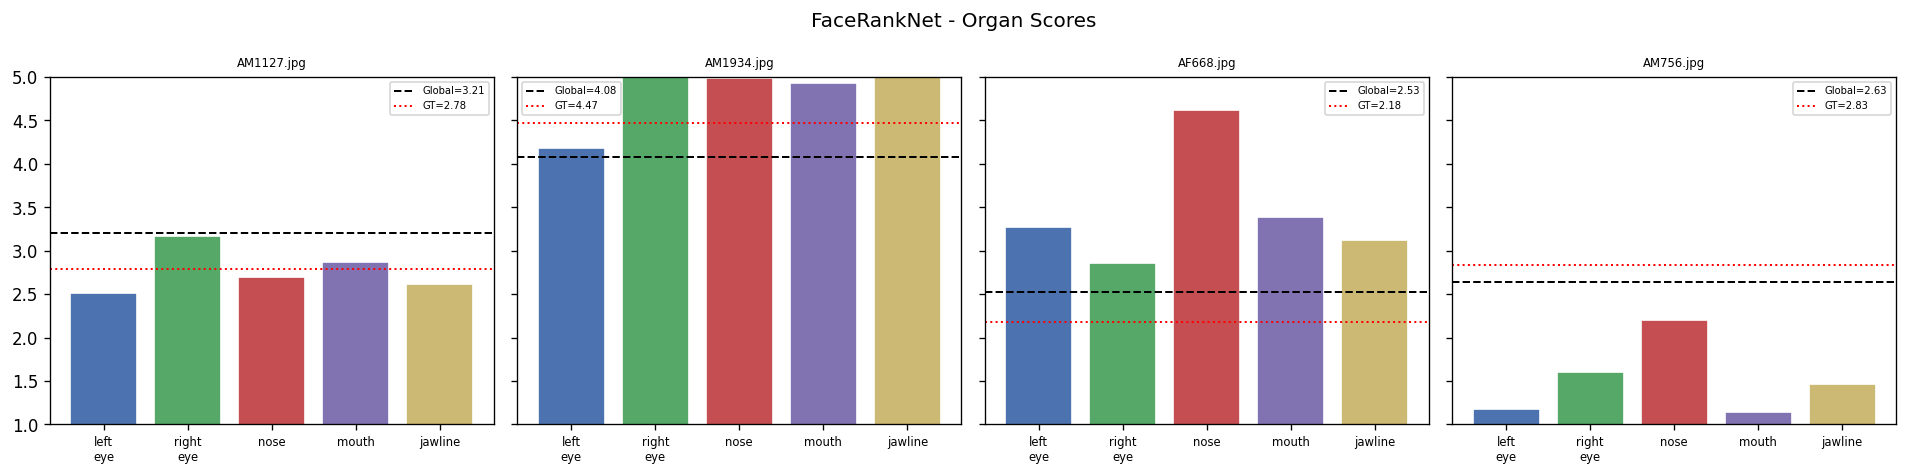

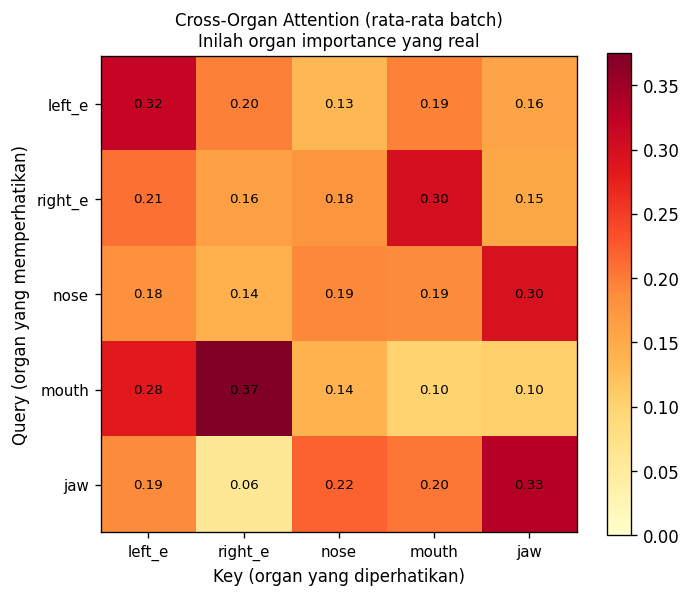

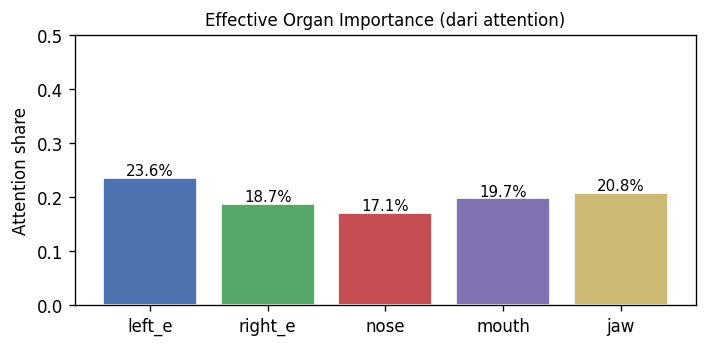

Figures saved to Drive.


In [13]:
# ============================================================
# Cell 10 — Visualisation: organ bar chart + cross-organ attention heatmap
# ============================================================
import torch, matplotlib.pyplot as plt, matplotlib, numpy as np
from dataset import collate_faces
from torch.utils.data import DataLoader

matplotlib.rcParams['figure.dpi'] = 120
colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']

sample_batch = next(iter(DataLoader(
    test_face_ds, batch_size=4, shuffle=False, collate_fn=collate_faces)))

trained_model.eval()
with torch.no_grad():
    sg  = {k: v.to(device) for k, v in sample_batch['subgraphs'].items()}
    out = trained_model(sg)

organ_names = list(out['local_scores'].keys())
n = len(sample_batch['filenames'])

# ── Fig 1: Organ score bar chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, n, figsize=(4*n, 4), sharey=True)
if n == 1: axes = [axes]
for i, ax in enumerate(axes):
    scores = [out['local_scores'][o][i].item() for o in organ_names]
    ax.bar(organ_names, scores, color=colors, edgecolor='white')
    ax.axhline(out['global_score'][i].item(), color='black', ls='--', lw=1.2,
               label=f'Global={out["global_score"][i].item():.2f}')
    ax.axhline(sample_batch['ratings'][i].item(), color='red', ls=':', lw=1.2,
               label=f'GT={sample_batch["ratings"][i].item():.2f}')
    ax.set_ylim(1, 5); ax.set_title(sample_batch['filenames'][i], fontsize=7)
    ax.set_xticklabels([o.replace('_','\n') for o in organ_names], fontsize=7)
    ax.legend(fontsize=6)
fig.suptitle('FaceRankNet - Organ Scores', fontsize=12)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/organ_scores_bar.png', bbox_inches='tight')
plt.show()

# ── Fig 2: Cross-organ attention heatmap (real learned importance) ──────────
# attn_weights: (B, 5, 5) — averaged across batch & heads
attn = out['attn_weights'].cpu().numpy()   # (B, num_heads*5, 5) or (B, 5, 5)
attn_mean = attn.mean(axis=0)              # (5, 5) — mean across batch

short_names = [o.replace('_eye','_e').replace('jawline','jaw') for o in organ_names]
fig2, ax2 = plt.subplots(figsize=(6, 5))
im = ax2.imshow(attn_mean, cmap='YlOrRd', vmin=0, vmax=attn_mean.max())
ax2.set_xticks(range(len(organ_names))); ax2.set_xticklabels(short_names, fontsize=9)
ax2.set_yticks(range(len(organ_names))); ax2.set_yticklabels(short_names, fontsize=9)
ax2.set_xlabel('Key (organ yang diperhatikan)'); ax2.set_ylabel('Query (organ yang memperhatikan)')
for i in range(len(organ_names)):
    for j in range(len(organ_names)):
        ax2.text(j, i, f'{attn_mean[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax2)
ax2.set_title('Cross-Organ Attention (rata-rata batch)\nInilah organ importance yang real', fontsize=10)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/cross_organ_attention.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Fig 3: Row-sum = effective attention received per organ ──────────────────
received = attn_mean.sum(axis=0)   # berapa banyak "attention" diterima tiap organ
fig3, ax3 = plt.subplots(figsize=(6, 3))
ax3.bar(short_names, received / received.sum(), color=colors, edgecolor='white')
ax3.set_ylabel('Attention share'); ax3.set_title('Effective Organ Importance (dari attention)', fontsize=10)
ax3.set_ylim(0, 0.5)
for i, v in enumerate(received / received.sum()):
    ax3.text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/organ_importance_attention.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figures saved to Drive.')

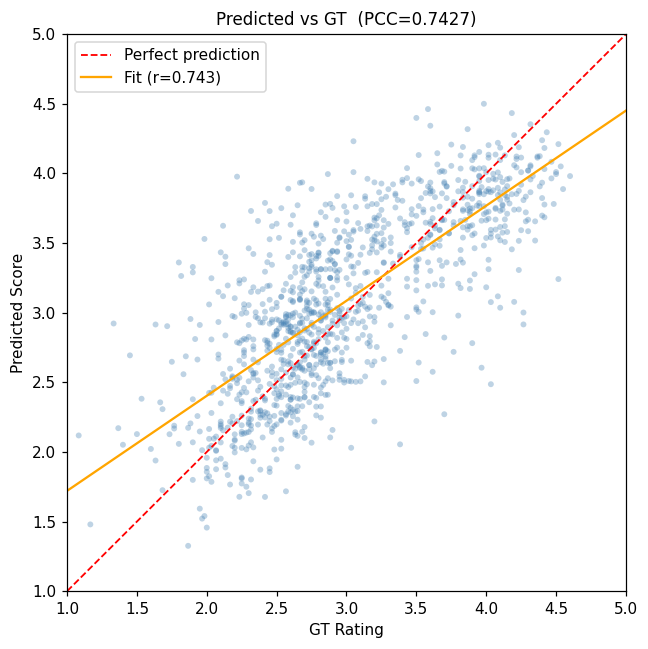

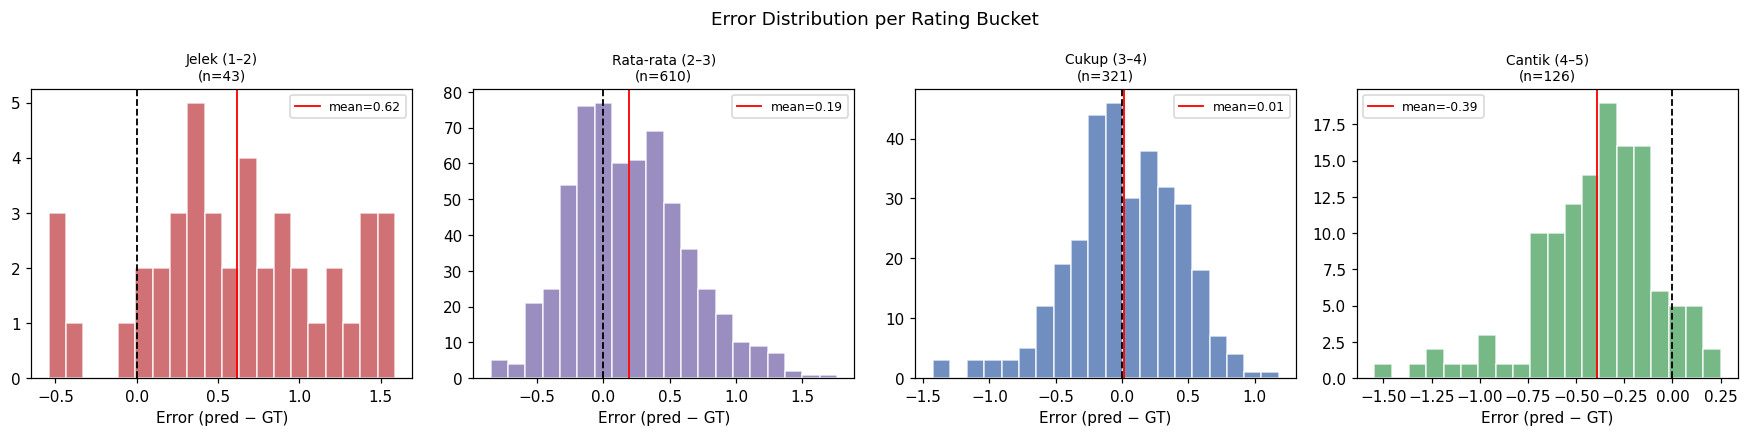

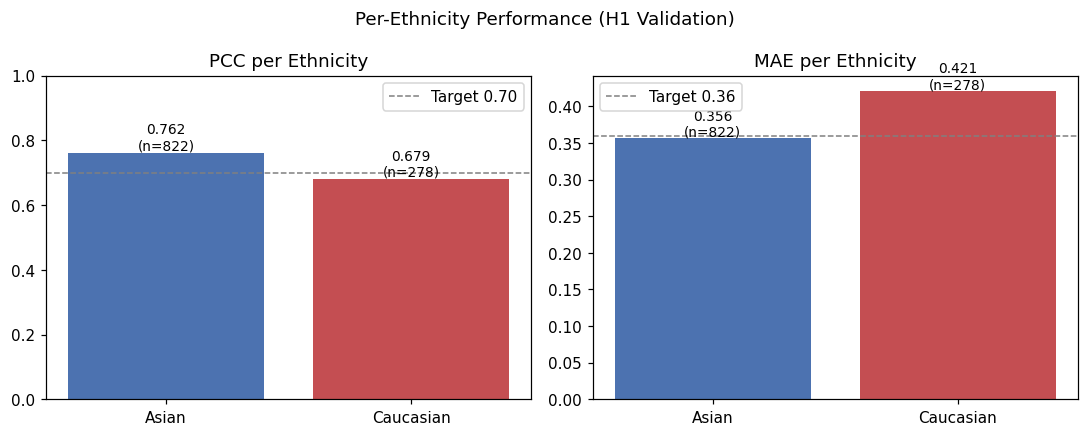

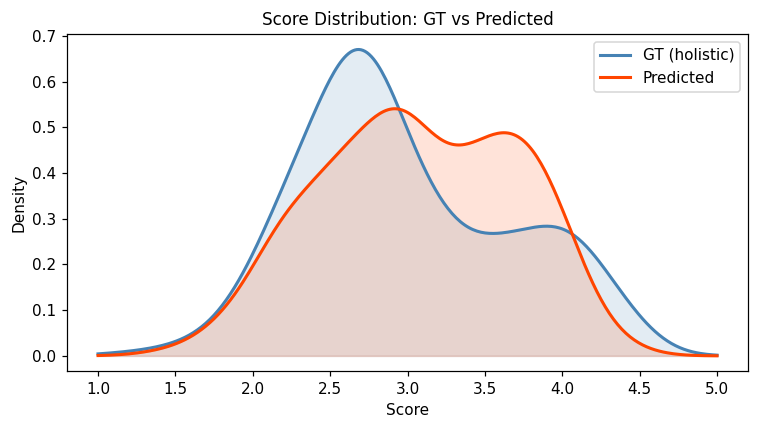


Top-K Ranking Precision:
     K |  Precision |   Recall
------------------------------
    10 |       0.0% |     0.0%
    25 |      16.0% |    16.0%
    50 |      28.0% |    28.0%
   100 |      43.0% |    43.0%


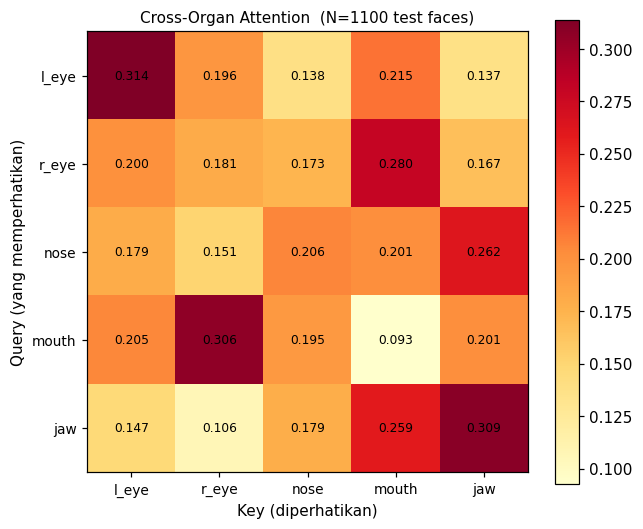


Semua figure tersimpan ke Drive.


In [14]:
# ============================================================
# Cell 11 — Extended Evaluation
# 1. Scatter predicted vs GT
# 2. Error distribution per rating bucket
# 3. PCC/MAE per ethnicity (H1 check)
# 4. Score distribution KDE
# 5. Top-K ranking precision
# 6. Full test-set attention heatmap
# ============================================================
import torch, numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib
from scipy import stats
from torch.utils.data import DataLoader
from dataset import collate_faces

matplotlib.rcParams['figure.dpi'] = 110

# ── Collect all predictions on test set ─────────────────────────────────────
trained_model.eval()
all_preds, all_gts, all_files = [], [], []
all_attn = []

with torch.no_grad():
    for batch in DataLoader(test_face_ds, batch_size=64, shuffle=False, collate_fn=collate_faces):
        sg  = {k: v.to(device) for k, v in batch['subgraphs'].items()}
        out = trained_model(sg)
        all_preds.extend(out['global_score'].cpu().numpy())
        all_gts.extend(batch['ratings'].numpy())
        all_files.extend(batch['filenames'])
        all_attn.append(out['attn_weights'].cpu().numpy())   # (B, 5, 5)

preds = np.array(all_preds)
gts   = np.array(all_gts)
files = np.array(all_files)
errors = preds - gts

# ── 1. Scatter plot: Predicted vs GT ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(gts, preds, alpha=0.35, s=15, color='steelblue', edgecolors='none')
lims = [1, 5]
ax.plot(lims, lims, 'r--', lw=1.2, label='Perfect prediction')
# Regression line
m, b, r, p, _ = stats.linregress(gts, preds)
xs = np.linspace(1, 5, 100)
ax.plot(xs, m*xs + b, 'orange', lw=1.5, label=f'Fit (r={r:.3f})')
ax.set_xlabel('GT Rating'); ax.set_ylabel('Predicted Score')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title(f'Predicted vs GT  (PCC={np.corrcoef(gts, preds)[0,1]:.4f})', fontsize=11)
ax.legend(); plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/scatter_pred_vs_gt.png', bbox_inches='tight', dpi=150)
plt.show()

# ── 2. Error distribution per rating bucket ──────────────────────────────────
buckets = {'Jelek (1–2)': (1, 2), 'Rata-rata (2–3)': (2, 3),
           'Cukup (3–4)': (3, 4), 'Cantik (4–5)': (4, 5)}
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
colors4 = ['#C44E52','#8172B2','#4C72B0','#55A868']
for ax, (label, (lo, hi)), c in zip(axes, buckets.items(), colors4):
    mask = (gts >= lo) & (gts < hi)
    err  = errors[mask]
    ax.hist(err, bins=20, color=c, alpha=0.8, edgecolor='white')
    ax.axvline(0, color='black', lw=1.2, ls='--')
    ax.axvline(err.mean(), color='red', lw=1.2, ls='-', label=f'mean={err.mean():.2f}')
    ax.set_title(f'{label}\n(n={mask.sum()})', fontsize=9)
    ax.set_xlabel('Error (pred − GT)'); ax.legend(fontsize=8)
fig.suptitle('Error Distribution per Rating Bucket', fontsize=12)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/error_per_bucket.png', bbox_inches='tight', dpi=150)
plt.show()

# ── 3. PCC & MAE per ethnicity (H1 evaluation) ───────────────────────────────
test_df_loaded = pd.read_csv(TEST_CSV)
eth_map = dict(zip(test_df_loaded['Filename'], test_df_loaded['Ethnicity']))
ethnicities = {'Asian': [], 'Caucasian': []}
for f, p, g in zip(files, preds, gts):
    eth = eth_map.get(f, 'Unknown')
    if eth in ethnicities:
        ethnicities[eth].append((p, g))

eth_metrics = {}
for eth, vals in ethnicities.items():
    if not vals: continue
    ps, gs = zip(*vals)
    ps, gs = np.array(ps), np.array(gs)
    eth_metrics[eth] = {
        'PCC': float(np.corrcoef(ps, gs)[0,1]),
        'MAE': float(np.abs(ps - gs).mean()),
        'n'  : len(ps)
    }

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
eth_names = list(eth_metrics.keys())
pccs = [eth_metrics[e]['PCC'] for e in eth_names]
maes = [eth_metrics[e]['MAE'] for e in eth_names]
ns   = [eth_metrics[e]['n']   for e in eth_names]

axes[0].bar(eth_names, pccs, color=['#4C72B0','#C44E52'])
axes[0].set_ylim(0, 1); axes[0].set_title('PCC per Ethnicity')
axes[0].axhline(0.70, color='gray', ls='--', lw=1, label='Target 0.70')
for i, (v, n) in enumerate(zip(pccs, ns)):
    axes[0].text(i, v+0.01, f'{v:.3f}\n(n={n})', ha='center', fontsize=9)
axes[0].legend()

axes[1].bar(eth_names, maes, color=['#4C72B0','#C44E52'])
axes[1].set_title('MAE per Ethnicity')
axes[1].axhline(0.36, color='gray', ls='--', lw=1, label='Target 0.36')
for i, (v, n) in enumerate(zip(maes, ns)):
    axes[1].text(i, v+0.003, f'{v:.3f}\n(n={n})', ha='center', fontsize=9)
axes[1].legend()

fig.suptitle('Per-Ethnicity Performance (H1 Validation)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/ethnicity_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

# ── 4. Score distribution KDE ────────────────────────────────────────────────
from scipy.stats import gaussian_kde
fig, ax = plt.subplots(figsize=(7, 4))
xs = np.linspace(1, 5, 300)
for arr, label, c in [(gts, 'GT (holistic)', 'steelblue'), (preds, 'Predicted', 'orangered')]:
    kde = gaussian_kde(arr, bw_method=0.3)
    ax.plot(xs, kde(xs), label=label, lw=2, color=c)
    ax.fill_between(xs, kde(xs), alpha=0.15, color=c)
ax.set_xlabel('Score'); ax.set_ylabel('Density')
ax.set_title('Score Distribution: GT vs Predicted', fontsize=11)
ax.legend(); plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/score_distribution_kde.png', bbox_inches='tight', dpi=150)
plt.show()

# ── 5. Top-K ranking precision ───────────────────────────────────────────────
# "Berapa % wajah cantik (GT top-K) yang juga ada di prediksi top-K?"
print("\nTop-K Ranking Precision:")
print(f"{'K':>6} | {'Precision':>10} | {'Recall':>8}")
print("-" * 30)
gt_rank   = np.argsort(-gts)
pred_rank = np.argsort(-preds)
for k in [10, 25, 50, 100]:
    top_gt   = set(gt_rank[:k])
    top_pred = set(pred_rank[:k])
    prec = len(top_gt & top_pred) / k
    rec  = len(top_gt & top_pred) / k
    print(f"{k:>6} | {prec:>10.1%} | {rec:>8.1%}")

# ── 6. Full test-set attention heatmap ──────────────────────────────────────
organ_names = ['left_eye','right_eye','nose','mouth','jawline']
short_names  = ['l_eye','r_eye','nose','mouth','jaw']
attn_all = np.concatenate(all_attn, axis=0)   # (N, 5, 5)
attn_mean = attn_all.mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn_mean, cmap='YlOrRd')
ax.set_xticks(range(5)); ax.set_xticklabels(short_names, fontsize=9)
ax.set_yticks(range(5)); ax.set_yticklabels(short_names, fontsize=9)
ax.set_xlabel('Key (diperhatikan)'); ax.set_ylabel('Query (yang memperhatikan)')
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{attn_mean[i,j]:.3f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax)
ax.set_title(f'Cross-Organ Attention  (N={len(attn_all)} test faces)', fontsize=10)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/attention_fulltest.png', bbox_inches='tight', dpi=150)
plt.show()
print('\nSemua figure tersimpan ke Drive.')